<a href="https://colab.research.google.com/github/manasiphand/PlantCareAI/blob/main/PlantCareAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

zip_path = '/content/drive/MyDrive/dataset/archive.zip'


!unzip -q "{zip_path}" -d /content/plant_data

In [ ]:
!pip install -q kaggle "tensorflow>=2.17.0" gradio matplotlib

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import os
if not os.path.exists("/content/new-plant-diseases-dataset"):
  !kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p/content
  !unzip -q /content/new-plant-diseases-dataset.zip -d /content/new-plant-diseases-dataset
  !ls -lah /content/new-plant-diseases-dataset | sed -n '1,200p'

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
new-plant-diseases-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
total 20K
drwxr-xr-x 5 root root 4.0K Mar  7 17:38 .
drwxr-xr-x 1 root root 4.0K Mar  7 17:37 ..
drwxr-xr-x 3 root root 4.0K Mar  7 17:37 new plant diseases dataset(augmented)
drwxr-xr-x 3 root root 4.0K Mar  7 17:37 New Plant Diseases Dataset(Augmented)
drwxr-xr-x 3 root root 4.0K Mar  7 17:38 test


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 5
N_LAST_LAYERS = 10 #Unfreeze last 10 layers for fine-tuning
SEED = 1337

#Dataset paths
train_dir = "/content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_dir = "/content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid"

#Verify paths exist
for p in [train_dir, valid_dir]:
  if not os.path.exists(p):
    print(f"ERROR: path not found: {p}")
    sys.exit(1)

print("train_dir:", train_dir)
print("valid_dir:", valid_dir)

train_dir: /content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train
valid_dir: /content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid


In [ ]:
import random
from IPython.display import Image, display

# Function to display random samples from each class
def show_sample_images (base_path, num_classes=5, images_per_class=3):
  """Display random sample images from the dataset"""
  class_names = os.listdir (base_path)
  random_classes = random.sample(class_names, min(num_classes, len(class_names)))

  fig, axes = plt.subplots (num_classes, images_per_class, figsize=(12, 3*num_classes))
  fig.suptitle('Sample Images from Dataset', fontsize=16)

  for i, class_name in enumerate(random_classes):
    class_path = os.path.join(base_path, class_name)
    images = os.listdir(class_path)
    random_images = random.sample(images, min(images_per_class, len(images)))

    for j, img_name in enumerate(random_images):
      img_path = os.path.join(class_path, img_name)
      img = plt.imread(img_path)
      axes[i, j].imshow(img)
      axes[i, j].axis('off')
      if j == 0:
        axes[i, j].set_title(class_name.replace('_', '\n'), fontsize=10)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
# Count images in each split
def count_images (directory):
  """Count total images and images per class"""
  total_images = 0
  class_counts = {}

  for class_name in os.listdir(directory):
    class_path = os.path.join(directory, class_name)
    if os.path.isdir(class_path):
      num_images = len(os.listdir(class_path))
      class_counts[class_name] = num_images
      total_images += num_images

  return total_images, class_counts

# Get statistics
train_total, train_counts = count_images(train_dir)
valid_total, valid_counts = count_images(valid_dir)

print(f"Training images: {train_total}")
print(f"Validation images: {valid_total}")
print(f"Number of classes: {len(train_counts)}")
print(f"\nClass distribution (first 10):")

for i, (class_name, count) in enumerate (list(train_counts.items())[:10]):
  print(f" {class_name}: {count} images")


Training images: 70295
Validation images: 17572
Number of classes: 38

Class distribution (first 10):
 Soybean___healthy: 2022 images
 Cherry_(including_sour)___healthy: 1826 images
 Blueberry___healthy: 1816 images
 Potato___Early_blight: 1939 images
 Tomato___healthy: 1926 images
 Strawberry___Leaf_scorch: 1774 images
 Peach___healthy: 1728 images
 Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1961 images
 Squash___Powdery_mildew: 1736 images
 Tomato___Septoria_leaf_spot: 1745 images


In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Training data generator with light augmentation
train_datagen = ImageDataGenerator(
  preprocessing_function=preprocess_input,
  horizontal_flip=True,
  rotation_range=20,
  zoom_range=0.15,
  width_shift_range=0.1,
  height_shift_range=0.1,
  fill_mode='reflect'
)

# Validation data generator (no augmentation)
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Create data generators
train_gen = train_datagen.flow_from_directory(
  train_dir,
  target_size=IMG_SIZE,
  batch_size=BATCH_SIZE,
  class_mode='categorical',
  shuffle=True,
  seed=SEED
)

valid_gen = valid_datagen.flow_from_directory(
  valid_dir,
  target_size=IMG_SIZE,
  batch_size=BATCH_SIZE,
  class_mode='categorical',
  shuffle=False
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import tensorflow as tf

print("Transfer Learning using MobileNetV2 is applied.")

Transfer Learning using MobileNetV2 is applied.


In [ ]:
IMG_SIZE = (224, 224)

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,     # remove original classifier
    input_shape=IMG_SIZE + (3,)
)

print("MobileNetV2 base model loaded successfully")
base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 base model loaded successfully


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last N layers for fine-tuning
N_LAST_LAYERS = 10

for layer in base_model.layers[-N_LAST_LAYERS:]:
    layer.trainable = True

print(f"Unfrozen last {N_LAST_LAYERS} layers for fine-tuning")

Unfrozen last 10 layers for fine-tuning


In [ ]:
from tensorflow.keras import layers

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(38, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

print("Custom plant disease classification model created")

Custom plant disease classification model created


In [ ]:
from tensorflow import keras

# Compile model with appropriate settings
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # low learning rate for transfer learning
    loss='categorical_crossentropy',                      # multi-class classification
    metrics=['accuracy']                                  # evaluation metric
)

print("Model compiled successfully!")

Model compiled successfully!


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Tumhi check kela to path ithe taka
base_dir = '/content/plant_data'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

valid_gen = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 140615 images belonging to 3 classes.
Found 35152 images belonging to 3 classes.


In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import tensorflow as tf

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

print("Model Architecture created successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Model Architecture created successfully!


In [5]:
from tensorflow import keras

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


checkpoint = ModelCheckpoint('plant_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


history = model.fit(
    train_gen,
    epochs=5,
    validation_data=valid_gen,
    callbacks=[checkpoint, early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4970 - loss: 0.7195
Epoch 1: val_accuracy improved from -inf to 0.49991, saving model to plant_model.keras
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 409s 88ms/step - accuracy: 0.4970 - loss: 0.7195 - val_accuracy: 0.4999 - val_loss: 0.6952
Epoch 2/5
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.4992 - loss: 0.6959
Epoch 2: val_accuracy did not improve from 0.49991
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 340s 77ms/step - accuracy: 0.4992 - loss: 0.6959 - val_accuracy: 0.4999 - val_loss: 0.6953
Epoch 3/5
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4991 - loss: 0.6957
Epoch 3: val_accuracy did not improve from 0.49991
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 287s 65ms/step - accuracy: 0.4991 - loss: 0.6957 - val_accuracy: 0.4999 - val_loss: 0.6951
Epoch 4/5
4394/4395 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4989 - loss: 0.6952
Epoch 4: val_accuracy did not improve from 0.49991
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 284s 65ms/s

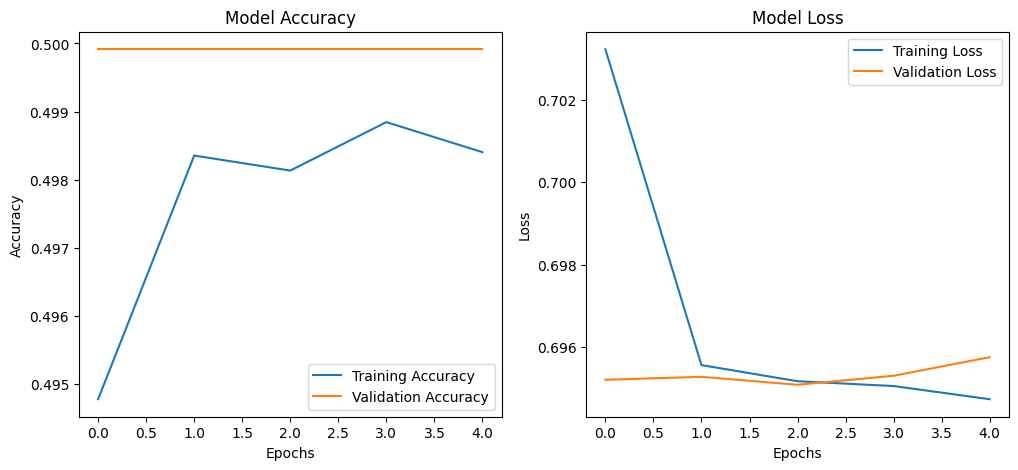

In [7]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [8]:

results = model.evaluate(valid_gen)

print(f"Validation Loss: {results[0]:.4f}")
print(f"Validation Accuracy: {results[1]*100:.2f}%")

1099/1099 ━━━━━━━━━━━━━━━━━━━━ 59s 53ms/step - accuracy: 0.5040 - loss: 0.6944
Validation Loss: 0.6951
Validation Accuracy: 49.99%


In [9]:

model.save('plant_disease_final_model.h5')

print("Final model saved successfully as plant_disease_final_model.h5")

Final model saved successfully as plant_disease_final_model.h5
